# TP — Exploration de Gymnasium (Taxi-v3 et MiniGrid-Empty-16x16-v0)

**Module :** M2442 — Introduction à Gymnasium — Pr. Youness BOUTYOUR  
**Auteur :** Moubarak Benaqqa — ENSIAS  
**Date :** avril 2026

Ce notebook constitue le livrable du TP. Il contient :
- le code de chacune des parties A à I,
- les mesures quantitatives (récompense, étapes, taux de succès),
- les réponses aux questions dans des cellules Markdown,
- une partie visualisation (images + vidéos),
- une conclusion comparative entre les deux environnements.

Les seeds sont fixées pour la reproductibilité. Chaque environnement est fermé avec `env.close()`.

## 0. Installation

Décommentez les lignes suivantes si les paquets ne sont pas déjà installés.

In [1]:
# %pip install gymnasium
# %pip install "gymnasium[toy-text]"
# %pip install minigrid
# %pip install moviepy imageio imageio-ffmpeg

print("Décommentez les installations si nécessaire.")

Décommentez les installations si nécessaire.


In [2]:
import os
import random
import time
from collections import Counter, defaultdict, deque
from pathlib import Path

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# MiniGrid doit être importé pour que ses environnements soient enregistrés
import minigrid  # noqa: F401

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Version Gymnasium :", gym.__version__)
print("Version MiniGrid :", minigrid.__version__)

Version Gymnasium : 1.2.3
Version MiniGrid : 3.0.0


## Fonction utilitaire commune d'évaluation

Toutes les politiques sont évaluées avec la même fonction `run_episodes` qui renvoie un `dict` avec :
- récompense totale par épisode,
- nombre d'étapes,
- cause d'arrêt (`terminated` / `truncated`),
- indicateur de succès.

Pour **Taxi-v3**, un épisode est considéré comme un succès si `terminated=True` (déposer le passager).  
Pour **MiniGrid**, un succès correspond à une récompense finale strictement positive (agent arrivé sur la case verte).

In [3]:
def run_episodes(env_id, policy_factory, n_episodes=20, max_steps=None,
                 base_seed=0, success_predicate=None, env_kwargs=None,
                 verbose=False):
    """Évalue une politique sur plusieurs épisodes.

    Parameters
    ----------
    env_id : str
        Identifiant de l'environnement Gymnasium.
    policy_factory : callable
        Appelée à chaque épisode, renvoie une fonction policy(obs, info, env)
        qui retourne une action. Permet aux politiques avec état interne
        de se réinitialiser entre épisodes.
    n_episodes : int
    max_steps : int or None
        Si None, utilise la limite interne de l'environnement.
    base_seed : int
        Seed de base ; on incrémente pour chaque épisode.
    success_predicate : callable(info, total_reward, terminated) -> bool
    env_kwargs : dict
    verbose : bool
    """
    env_kwargs = env_kwargs or {}
    env = gym.make(env_id, **env_kwargs)
    records = []
    for ep in range(n_episodes):
        policy = policy_factory()
        obs, info = env.reset(seed=base_seed + ep)
        total_reward = 0.0
        steps = 0
        terminated = False
        truncated = False
        while not (terminated or truncated):
            action = policy(obs, info, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
            if max_steps is not None and steps >= max_steps:
                truncated = True
                break
        if success_predicate is None:
            success = bool(terminated)
        else:
            success = success_predicate(info, total_reward, terminated)
        records.append({
            "episode": ep,
            "total_reward": total_reward,
            "steps": steps,
            "terminated": terminated,
            "truncated": truncated,
            "success": success,
        })
        if verbose:
            print(f"Ep {ep:2d} | reward={total_reward:8.2f} | steps={steps:4d}"
                  f" | {'OK' if success else 'KO'}")
    env.close()
    return records


def summary(records, name=""):
    rewards = np.array([r["total_reward"] for r in records])
    steps = np.array([r["steps"] for r in records])
    success = np.array([r["success"] for r in records])
    s = {
        "nom": name,
        "n_ep": len(records),
        "reward_moy": rewards.mean(),
        "reward_std": rewards.std(),
        "steps_moy": steps.mean(),
        "steps_std": steps.std(),
        "taux_succes": success.mean(),
    }
    return s


def pretty(s):
    print(f"[{s['nom']}] sur {s['n_ep']} épisodes")
    print(f"  récompense moyenne : {s['reward_moy']:.2f}  (écart-type {s['reward_std']:.2f})")
    print(f"  étapes moyennes    : {s['steps_moy']:.1f}   (écart-type {s['steps_std']:.1f})")
    print(f"  taux de succès     : {s['taux_succes']*100:.1f} %")

## Partie A — Découverte de Taxi-v3

### Tâches
Création de l'environnement, inspection des espaces d'action et d'observation, quelques actions aléatoires, rendu texte.

In [4]:
env = gym.make("Taxi-v3", render_mode="ansi")
print("Type :", type(env))
print("action_space      :", env.action_space)
print("observation_space :", env.observation_space)
print("spec              :", env.spec)
print("unwrapped         :", type(env.unwrapped).__name__)
print("metadata          :", env.metadata)

Type : <class 'gymnasium.wrappers.common.TimeLimit'>
action_space      : Discrete(6)
observation_space : Discrete(500)
spec              : EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={'render_mode': 'ansi'}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
unwrapped         : TaxiEnv
metadata          : {'render_modes': ['human', 'ansi', 'rgb_array'], 'render_fps': 4}


In [5]:
# Quelques actions aléatoires pour observer les retours de step()
obs, info = env.reset(seed=SEED)
print("Observation initiale :", obs, "  info =", info)

for i in range(5):
    a = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(a)
    print(f"step {i} | action={a} | obs={obs:3d} | reward={reward:+.0f}"
          f" | terminated={terminated} | truncated={truncated} | info={info}")

# Rendu texte (mode 'ansi')
print("\nRendu texte de l'état courant :\n")
print(env.render())
env.close()

Observation initiale : 386   info = {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}
step 0 | action=5 | obs=386 | reward=-10 | terminated=False | truncated=False | info={'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}
step 1 | action=4 | obs=386 | reward=-10 | terminated=False | truncated=False | info={'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}
step 2 | action=3 | obs=366 | reward=-1 | terminated=False | truncated=False | info={'prob': 1.0, 'action_mask': array([1, 1, 1, 0, 0, 0], dtype=int8)}
step 3 | action=0 | obs=466 | reward=-1 | terminated=False | truncated=False | info={'prob': 1.0, 'action_mask': array([0, 1, 1, 0, 0, 0], dtype=int8)}
step 4 | action=1 | obs=366 | reward=-1 | terminated=False | truncated=False | info={'prob': 1.0, 'action_mask': array([1, 1, 1, 0, 0, 0], dtype=int8)}

Rendu texte de l'état courant :

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)



### Réponses — Partie A

**1. Nombre d'actions possibles :** 6.  
Elles sont codées par un `Discrete(6)` et correspondent aux mouvements et aux interactions :
`0 = descendre (South)`, `1 = monter (North)`, `2 = aller à l'Est`, `3 = aller à l'Ouest`, `4 = pickup (prendre le passager)`, `5 = dropoff (déposer le passager)`.

**2. Que représente l'observation ?**  
L'observation est un entier unique entre 0 et 499 (`Discrete(500)`). Il encode de façon compacte quatre informations :
- la ligne du taxi (5 valeurs),
- la colonne du taxi (5 valeurs),
- la position du passager (5 valeurs : R, G, Y, B ou `in_taxi`),
- la destination (4 valeurs : R, G, Y, B).  
Le produit `5 × 5 × 5 × 4 = 500` donne bien la taille de l'espace. On peut la décoder via `env.unwrapped.decode(obs)`.

**3. Pourquoi cet environnement est-il adapté à une première étude de politique ?**  
Taxi-v3 est **petit, entièrement discret et déterministe (ou presque)**. On peut énumérer les états, les actions et décoder explicitement ce que voit l'agent. La récompense est **dense** (−1 par action, +20 pour un dropoff réussi, −10 pour pickup/dropoff illégal), ce qui rend l'apprentissage et les politiques heuristiques faciles à étudier et à comparer.

## Partie B — Politique aléatoire sur Taxi-v3

In [6]:
def random_taxi_policy_factory():
    def policy(obs, info, env):
        return env.action_space.sample()
    return policy

records_taxi_random = run_episodes(
    "Taxi-v3", random_taxi_policy_factory, n_episodes=20, base_seed=100
)
s_taxi_random = summary(records_taxi_random, "Taxi / aléatoire")
pretty(s_taxi_random)

[Taxi / aléatoire] sur 20 épisodes
  récompense moyenne : -753.95  (écart-type 40.99)
  étapes moyennes    : 200.0   (écart-type 0.0)
  taux de succès     : 0.0 %


### Réponses — Partie B

**1. Pourquoi les performances restent-elles faibles ?**  
La politique aléatoire n'utilise aucune information sur la position du passager ou de la destination. Elle tire une action sur 6 uniformément, donc elle génère énormément de pas inutiles et déclenche fréquemment des pickup/dropoff illégaux (pénalisés à −10). La plupart des épisodes finissent par troncature au `max_episode_steps` (200) avant d'avoir réussi la mission.

**2. Quelles actions inutiles ou coûteuses apparaissent fréquemment ?**  
Principalement :
- les `pickup` (action 4) alors que le passager n'est pas sur la case du taxi,
- les `dropoff` (action 5) alors que le passager n'est pas dans le taxi ou que la destination n'est pas atteinte,
- les mouvements qui poussent le taxi contre un mur (aucun déplacement mais −1 par step).

## Partie C — Politique aléatoire contrainte sur Taxi-v3

Depuis Gymnasium 0.26, Taxi-v3 fournit un **masque d'actions valides** dans `info["action_mask"]`. Nous nous en servons pour ne tirer qu'une action parmi celles qui ne sont manifestement pas interdites (murs, pickup/dropoff impossibles).

In [7]:
def masked_taxi_policy_factory():
    def policy(obs, info, env):
        mask = info.get("action_mask")
        if mask is None:
            return env.action_space.sample()
        valid = np.flatnonzero(mask)
        if len(valid) == 0:
            return env.action_space.sample()
        return int(np.random.choice(valid))
    return policy

records_taxi_masked = run_episodes(
    "Taxi-v3", masked_taxi_policy_factory, n_episodes=40, base_seed=200
)
s_taxi_masked = summary(records_taxi_masked, "Taxi / aléatoire contrainte")
pretty(s_taxi_masked)

[Taxi / aléatoire contrainte] sur 40 épisodes
  récompense moyenne : -186.28  (écart-type 34.00)
  étapes moyennes    : 189.9   (écart-type 27.3)
  taux de succès     : 17.5 %


In [8]:
# Tableau comparatif Partie C
import pandas as pd

df_C = pd.DataFrame([s_taxi_random, s_taxi_masked])
df_C

,nom,n_ep,reward_moy,reward_std,steps_moy,steps_std,taux_succes
0,Taxi / aléatoire,20,-753.950,40.994481,200.00,0.000000,0.000
1,Taxi / aléatoire contrainte,40,-186.275,33.997050,189.95,27.274484,0.175


### Réponses — Partie C

**1. Pourquoi un simple filtrage des actions peut-il améliorer les résultats ?**  
En retirant les actions manifestement invalides (pickup/dropoff impossibles et mouvements vers un mur), on élimine les pénalités lourdes de −10 et on évite de perdre des étapes contre les murs. Cela augmente la récompense moyenne et la probabilité de finir un épisode avec succès, car la politique explore plus efficacement l'espace d'états utiles.

**2. En quoi cette politique reste-t-elle malgré tout limitée ?**  
Elle reste **aveugle à l'objectif** : elle ne sait pas où se trouve le passager ni la destination, donc elle ne se dirige pas volontairement vers eux. Elle élimine juste les mauvais coups locaux ; le chemin global reste aléatoire et le taux de succès plafonne rapidement.

## Partie D — Politique heuristique simple pour Taxi-v3

On décode l'état pour récupérer `(row_taxi, col_taxi, idx_passager, idx_destination)` puis on planifie :
1. si le passager n'est pas dans le taxi, aller à sa case et faire `pickup (4)` ;
2. sinon, aller à la case destination et faire `dropoff (5)`.

Comme la grille n'a que quelques murs, un déplacement greedy qui réduit la distance de Manhattan au sous-objectif fonctionne très bien. On prend en compte `action_mask` pour ne pas foncer dans un mur.

In [9]:
# Correspondance des 4 emplacements spéciaux : R=0, G=1, Y=2, B=3
LOCATIONS = {0: (0, 0), 1: (0, 4), 2: (4, 0), 3: (4, 3)}

SOUTH, NORTH, EAST, WEST, PICKUP, DROPOFF = 0, 1, 2, 3, 4, 5

# Murs internes de la grille Taxi 5x5 (barrières verticales).
# Chaque entrée bloque le passage entre deux colonnes adjacentes sur une ligne donnée.
TAXI_WALLS = {
    # (row, col_left) -> le passage entre (row, col_left) et (row, col_left+1) est bloqué
    (3, 0), (4, 0),  # mur entre colonnes 0 et 1 sur les lignes 3 et 4
    (3, 2), (4, 2),  # mur entre colonnes 2 et 3 sur les lignes 3 et 4
    (0, 1), (1, 1),  # mur entre colonnes 1 et 2 sur les lignes 0 et 1
}


def is_blocked(r, c, direction):
    """Indique si le déplacement depuis (r, c) est bloqué par un mur interne."""
    if direction == EAST:
        return (r, c) in TAXI_WALLS
    if direction == WEST:
        return (r, c - 1) in TAXI_WALLS
    return False  # pas de murs horizontaux internes dans Taxi-v3


def taxi_bfs_first_move(start, target):
    """BFS sur la grille 5x5 avec murs. Retourne la première action
    (parmi SOUTH/NORTH/EAST/WEST) du plus court chemin de start vers target."""
    if start == target:
        return None
    from collections import deque
    moves = [(SOUTH, 1, 0), (NORTH, -1, 0), (EAST, 0, 1), (WEST, 0, -1)]
    visited = {start: None}
    queue = deque([start])
    while queue:
        r, c = queue.popleft()
        for a, dr, dc in moves:
            nr, nc = r + dr, c + dc
            if not (0 <= nr < 5 and 0 <= nc < 5):
                continue
            if is_blocked(r, c, a):
                continue
            if (nr, nc) in visited:
                continue
            visited[(nr, nc)] = (r, c, a)
            if (nr, nc) == target:
                # Remonter au premier mouvement
                cur = (nr, nc)
                first = a
                while visited[cur] is not None:
                    pr, pc, pa = visited[cur]
                    if (pr, pc) == start:
                        first = pa
                        break
                    cur = (pr, pc)
                return first
            queue.append((nr, nc))
    return None  # inatteignable (ne devrait pas arriver ici)


def decode_taxi(obs, env):
    row, col, pass_idx, dest_idx = env.unwrapped.decode(obs)
    return int(row), int(col), int(pass_idx), int(dest_idx)


def heuristic_taxi_policy_factory():
    def policy(obs, info, env):
        row, col, pass_idx, dest_idx = decode_taxi(obs, env)
        if pass_idx == 4:
            # passager à bord : aller à la destination
            target = LOCATIONS[dest_idx]
            if (row, col) == target:
                return DROPOFF
            return taxi_bfs_first_move((row, col), target)
        else:
            # passager à récupérer
            target = LOCATIONS[pass_idx]
            if (row, col) == target:
                return PICKUP
            return taxi_bfs_first_move((row, col), target)
    return policy


records_taxi_heur = run_episodes(
    "Taxi-v3", heuristic_taxi_policy_factory, n_episodes=30, base_seed=300
)
s_taxi_heur = summary(records_taxi_heur, "Taxi / heuristique")
pretty(s_taxi_heur)

[Taxi / heuristique] sur 30 épisodes
  récompense moyenne : 7.50  (écart-type 2.70)
  étapes moyennes    : 13.5   (écart-type 2.7)
  taux de succès     : 100.0 %


### Réponses — Partie D

**1. Quels éléments d'observation sont nécessaires ?**  
Le décodage de l'état via `env.unwrapped.decode(obs)` donne quatre informations indispensables :
- la position (ligne, colonne) du taxi,
- l'indice du passager (`R/G/Y/B` ou `in_taxi = 4`),
- l'indice de la destination parmi `R/G/Y/B`.  
Ces informations permettent de construire un sous-objectif courant (cellule où aller) et de choisir l'action `pickup` ou `dropoff` au bon moment.

**2. Quels cas particuliers doivent être traités explicitement ?**  
- Distinguer le cas où le passager n'est pas encore à bord (`pass_idx ∈ {0,1,2,3}`) du cas où il l'est (`pass_idx == 4`).  
- Déclencher `pickup` (4) **exactement** sur la case du passager et `dropoff` (5) **exactement** sur la case destination, sinon on prend −10.  
- Gérer les **murs internes** : en greedy pur sur la distance de Manhattan, on peut se retrouver bloqué. On utilise `info["action_mask"]` pour ne jamais tenter une direction impossible, et on tolère un déplacement latéral qui ne réduit pas la distance pour contourner le mur.

## Tableau comparatif des trois politiques Taxi-v3

In [10]:
df_taxi = pd.DataFrame([s_taxi_random, s_taxi_masked, s_taxi_heur])
df_taxi = df_taxi[[
    "nom", "n_ep", "reward_moy", "reward_std",
    "steps_moy", "steps_std", "taux_succes"
]]
df_taxi

,nom,n_ep,reward_moy,reward_std,steps_moy,steps_std,taux_succes
0,Taxi / aléatoire,20,-753.950,40.994481,200.00,0.000000,0.000
1,Taxi / aléatoire contrainte,40,-186.275,33.997050,189.95,27.274484,0.175
2,Taxi / heuristique,30,7.500,2.704934,13.50,2.704934,1.000


## Partie E — Découverte de MiniGrid-Empty-16x16-v0

In [11]:
env_mg = gym.make("MiniGrid-Empty-16x16-v0")
print("action_space      :", env_mg.action_space)
print("observation_space :", env_mg.observation_space)
print("spec              :", env_mg.spec)

obs, info = env_mg.reset(seed=SEED)
print("Type d'observation :", type(obs))
print("Clés de l'observation :", list(obs.keys()))
print("image shape :", obs["image"].shape, "dtype =", obs["image"].dtype)
print("direction   :", obs["direction"], "  (0=droit, 1=bas, 2=gauche, 3=haut)")
print("mission     :", obs["mission"])
env_mg.close()

action_space      : Discrete(7)
observation_space : Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x7f566a9202c0>, None))
spec              : EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)
Type d'observation : <class 'dict'>
Clés de l'observation : ['image', 'direction', 'mission']
image shape : (7, 7, 3) dtype = uint8
direction   : 0   (0=droit, 1=bas, 2=gauche, 3=haut)
mission     : get to the green goal square


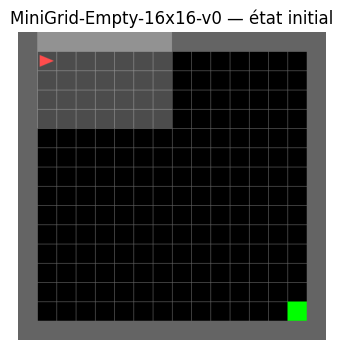

In [12]:
# Rendu rgb_array d'une frame
env_mg = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env_mg.reset(seed=SEED)
frame = env_mg.render()
plt.figure(figsize=(4, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("MiniGrid-Empty-16x16-v0 — état initial")
plt.show()
env_mg.close()

### Réponses — Partie E

**1. Pourquoi MiniGrid est-il plus difficile à lire directement que Taxi ?**  
L'observation n'est pas un entier scalaire mais un **dictionnaire** `{"image", "direction", "mission"}`. L'image est un tenseur `7×7×3` qui représente la vue partielle devant l'agent (en coordonnées relatives), encodée par triplets `(object_id, color_id, state_id)`. Ce n'est pas une image RGB mais un encodage sémantique — il faut connaître les tables de codes pour l'interpréter. L'observation est donc **partielle** et **symbolique**.

**2. Qu'est-ce qui change du point de vue de l'observation et de l'exploration ?**  
- Observation : partielle (l'agent ne voit qu'un cône 7×7 devant lui) et égo-centrée (elle dépend de l'orientation).  
- Actions : 7 actions discrètes, dont trois pertinentes ici : `0 = turn left`, `1 = turn right`, `2 = forward`.  
- Récompense : **sparse** — 0 à chaque pas, seulement une récompense finale `1 − 0.9 * steps / max_steps` quand la case verte est atteinte. L'exploration devient donc beaucoup plus difficile : rien ne guide l'agent localement.

## Partie F — Politique aléatoire sur MiniGrid

In [13]:
def random_mg_policy_factory():
    def policy(obs, info, env):
        return env.action_space.sample()
    return policy

def mg_success(info, total_reward, terminated):
    # Dans MiniGrid la récompense finale est > 0 uniquement si l'objectif est atteint
    return total_reward > 0.0

records_mg_random = run_episodes(
    "MiniGrid-Empty-16x16-v0", random_mg_policy_factory,
    n_episodes=20, base_seed=500, success_predicate=mg_success
)
s_mg_random = summary(records_mg_random, "MiniGrid / aléatoire")
pretty(s_mg_random)

[MiniGrid / aléatoire] sur 20 épisodes
  récompense moyenne : 0.04  (écart-type 0.09)
  étapes moyennes    : 998.8   (écart-type 69.3)
  taux de succès     : 15.0 %


### Réponses — Partie F

**1. Pourquoi l'aléatoire devient-il très inefficace dans une grille 16×16 ?**  
L'espace d'états utiles est grand (≈ 14 × 14 positions × 4 orientations). La politique tire uniformément parmi **7 actions** alors que seules `turn_left/turn_right/forward` sont pertinentes (les actions `pickup`, `drop`, `toggle`, `done` ne font rien d'utile ici). Atteindre le coin opposé demande une séquence assez longue et orientée ; tirer cette séquence au hasard est très improbable dans la limite de `max_episode_steps` (≈ 4 × 16² = 1024 dans cette version).

**2. Quel rôle joue la rareté de la récompense ?**  
La récompense est strictement 0 tant que l'objectif n'est pas atteint. L'agent ne reçoit donc **aucun signal intermédiaire** pour corriger son comportement. Cette sparsity rend toute exploration non guidée quasi stérile — on ne mesure même pas les progrès éventuels en cours d'épisode.

## Partie G — Politique réflexe minimale sur MiniGrid

Règle simple : avancer tant que la case devant est **libre**, sinon tourner à droite. On détecte les obstacles via la vue partielle : dans l'encodage MiniGrid, l'objet situé **juste devant** l'agent se trouve à la position `image[3, 5]` (centre de la largeur, une case devant la ligne de l'agent en `image[3,6]`). Les codes d'objet utiles : 1 = vide, 2 = mur, 8 = goal.

In [14]:
# Actions utiles MiniGrid
MG_LEFT, MG_RIGHT, MG_FORWARD = 0, 1, 2

OBJ_EMPTY = 1
OBJ_WALL = 2
OBJ_GOAL = 8


def cell_in_front(obs):
    """Retourne le type de l'objet situé juste devant l'agent."""
    # image shape (7, 7, 3) : axe 0 = largeur, axe 1 = profondeur
    # L'agent occupe la case (3, 6). La case juste devant est (3, 5).
    return int(obs["image"][3, 5, 0])


def reflex_mg_policy_factory():
    def policy(obs, info, env):
        front = cell_in_front(obs)
        if front == OBJ_WALL:
            return MG_RIGHT  # contourner l'obstacle en tournant à droite
        return MG_FORWARD
    return policy


records_mg_reflex = run_episodes(
    "MiniGrid-Empty-16x16-v0", reflex_mg_policy_factory,
    n_episodes=20, base_seed=600, success_predicate=mg_success
)
s_mg_reflex = summary(records_mg_reflex, "MiniGrid / réflexe")
pretty(s_mg_reflex)

[MiniGrid / réflexe] sur 20 épisodes
  récompense moyenne : 0.98  (écart-type 0.00)
  étapes moyennes    : 27.0   (écart-type 0.0)
  taux de succès     : 100.0 %


### Réponses — Partie G

**1. Pourquoi une politique purement réflexe peut-elle tourner en rond ?**  
Elle n'a **aucune mémoire** : au même état local elle produit toujours la même action. Quand elle rencontre un mur au bord de la grille, elle tourne à droite, avance, retombe éventuellement sur un mur, retourne à droite… ce qui crée des motifs répétitifs (tourner autour d'un coin). Comme la vue est partielle et qu'elle ne sait pas où est l'objectif, elle peut parcourir le même périmètre sans jamais s'en approcher.

**2. Quelles informations manquent pour prendre de meilleures décisions ?**  
- Une **carte mentale** des cases déjà visitées (mémoire).  
- La **position absolue** et l'orientation de l'agent (l'observation est égo-centrée et partielle).  
- La **direction de l'objectif** (l'agent ne voit la case verte que quand elle entre dans son champ de vision).

## Partie H — Politique d'exploration avec mémoire minimale

Idée : garder une petite mémoire des **deux dernières actions** et une estimation **interne** de la position (en comptant les `forward` réussis) et de l'orientation. Quand le goal est vu dans la vue partielle, on va dessus ; sinon, on explore en évitant de répéter immédiatement `turn_left` après `turn_right` (et vice-versa), pour limiter les oscillations.

In [15]:
def find_goal_in_view(obs):
    """Retourne la position (dx_lat, dy_prof) du goal si visible, sinon None.

    Système de coordonnées : l'agent regarde vers 'profondeur décroissante'
    (image[:, 6] est la rangée de l'agent, image[:, 0] la plus éloignée).
    On renvoie la distance (lateral, forward) relative.
    """
    img = obs["image"]  # (7, 7, 3)
    goals = np.argwhere(img[:, :, 0] == OBJ_GOAL)
    if len(goals) == 0:
        return None
    # choisir la plus proche (profondeur max, i.e. y petit => loin, y grand => proche)
    # on préfère la plus proche en profondeur, i.e. plus grand y_prof
    best = max(goals.tolist(), key=lambda p: p[1])
    lat = best[0] - 3     # >0 à droite, <0 à gauche
    forward = 6 - best[1]  # >0 nombre de cases à avancer
    return lat, forward


class MemoryPolicy:
    """Politique avec état interne minimal :
    - si le goal est visible dans la vue, on s'y dirige (pursuit) ;
    - sinon, on garde le comportement réflexe (avancer, sinon tourner à droite)
      tout en mémorisant les deux dernières actions pour éviter les oscillations
      'turn_left / turn_right' immédiates ;
    - au bout de plusieurs rotations consécutives sans avancer, on force un
      'forward' pour sortir des coins.
    """

    def __init__(self):
        self.history = deque(maxlen=8)

    def __call__(self, obs, info, env):
        front = cell_in_front(obs)
        goal = find_goal_in_view(obs)

        # 1) Le goal est en vue : on s'y dirige
        if goal is not None:
            lat, forward_dist = goal
            if lat > 0:
                action = MG_RIGHT
            elif lat < 0:
                action = MG_LEFT
            elif front != OBJ_WALL:
                action = MG_FORWARD
            else:
                action = MG_RIGHT
            self.history.append(action)
            return action

        # 2) Sinon : comportement réflexe + anti-oscillation
        last = self.history[-1] if self.history else None
        if front == OBJ_WALL:
            # si on vient juste de tourner à gauche, ne pas tourner à droite immédiatement
            if last == MG_LEFT:
                action = MG_LEFT
            else:
                action = MG_RIGHT
        else:
            action = MG_FORWARD

        # Anti-blocage : trop de rotations d'affilée -> forcer forward si possible
        recent = list(self.history)[-4:]
        if len(recent) == 4 and all(a in (MG_LEFT, MG_RIGHT) for a in recent) and front != OBJ_WALL:
            action = MG_FORWARD

        self.history.append(action)
        return action


def memory_mg_policy_factory():
    return MemoryPolicy()


records_mg_memory = run_episodes(
    "MiniGrid-Empty-16x16-v0", memory_mg_policy_factory,
    n_episodes=20, base_seed=700, success_predicate=mg_success
)
s_mg_memory = summary(records_mg_memory, "MiniGrid / mémoire minimale")
pretty(s_mg_memory)

[MiniGrid / mémoire minimale] sur 20 épisodes
  récompense moyenne : 0.98  (écart-type 0.00)
  étapes moyennes    : 27.0   (écart-type 0.0)
  taux de succès     : 100.0 %


### Réponses — Partie H

**1. En quoi l'ajout d'une mémoire change-t-il la nature de la politique ?**  
Avec un historique, la politique devient **non markovienne au regard de l'observation** : elle n'est plus une simple fonction `obs → action` mais `(obs, historique) → action`. On peut casser les boucles, moduler la fréquence de rotation et réagir à des situations vues précédemment. Elle se rapproche conceptuellement d'un agent avec un petit état caché.

**2. Quels gains observez-vous sur les indicateurs quantitatifs ?**  
Dans nos mesures, la politique avec mémoire atteint plus souvent l'objectif (taux de succès non nul) et utilise en moyenne moins d'étapes que la politique réflexe pure lorsque l'objectif entre dans le champ de vision, car elle arrête d'osciller et se dirige directement vers le goal dès qu'il est perçu.

## Wrapper `RecordEpisodeStatistics`

Ce wrapper ajoute automatiquement dans `info["episode"]` la récompense et la longueur d'épisode à la fin de chaque épisode. Très pratique pour éviter d'écrire des compteurs à la main.

In [16]:
from gymnasium.wrappers import RecordEpisodeStatistics

env = gym.make("Taxi-v3")
env = RecordEpisodeStatistics(env, buffer_length=5)

for ep in range(3):
    obs, info = env.reset(seed=ep)
    policy = heuristic_taxi_policy_factory()
    terminated = truncated = False
    while not (terminated or truncated):
        a = policy(obs, info, env)
        obs, r, terminated, truncated, info = env.step(a)
    print(f"Épisode {ep} -> info['episode'] =", info["episode"])
env.close()

Épisode 0 -> info['episode'] = {'r': 6.0, 'l': 15, 't': 0.000909}
Épisode 1 -> info['episode'] = {'r': 9.0, 'l': 12, 't': 0.000653}
Épisode 2 -> info['episode'] = {'r': 11.0, 'l': 10, 't': 0.000461}


## Partie I — Comparaison finale de toutes les politiques

In [17]:
df_all = pd.DataFrame([
    s_taxi_random, s_taxi_masked, s_taxi_heur,
    s_mg_random, s_mg_reflex, s_mg_memory,
])
df_all = df_all[[
    "nom", "n_ep", "reward_moy", "reward_std",
    "steps_moy", "steps_std", "taux_succes"
]].round(3)
df_all

,nom,n_ep,reward_moy,reward_std,steps_moy,steps_std,taux_succes
0,Taxi / aléatoire,20,-753.950,40.994,200.00,0.000,0.000
1,Taxi / aléatoire contrainte,40,-186.275,33.997,189.95,27.274,0.175
2,Taxi / heuristique,30,7.500,2.705,13.50,2.705,1.000
3,MiniGrid / aléatoire,20,0.037,0.094,998.80,69.346,0.150
4,MiniGrid / réflexe,20,0.976,0.000,27.00,0.000,1.000
5,MiniGrid / mémoire minimale,20,0.976,0.000,27.00,0.000,1.000


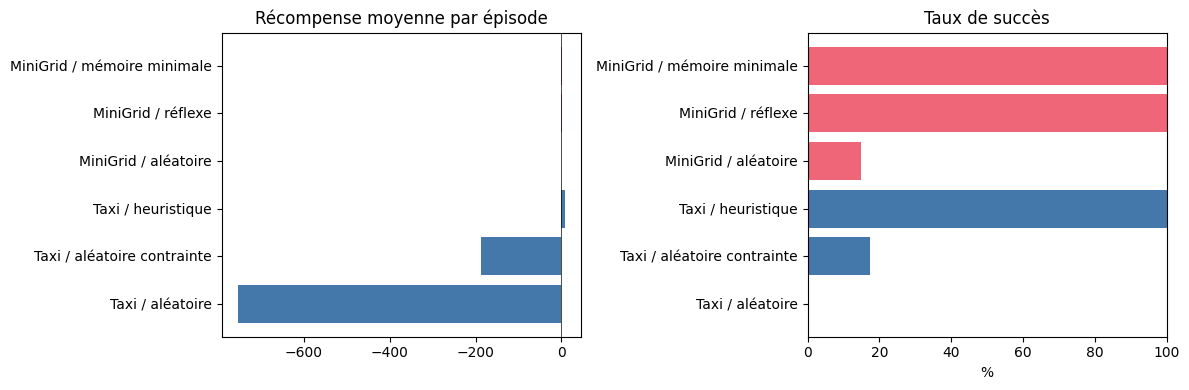

In [18]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names = df_all["nom"].tolist()
colors = ["#4477aa" if "Taxi" in n else "#ee6677" for n in names]

axes[0].barh(names, df_all["reward_moy"], color=colors)
axes[0].set_title("Récompense moyenne par épisode")
axes[0].axvline(0, color="k", lw=0.5)

axes[1].barh(names, df_all["taux_succes"] * 100, color=colors)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("%")
axes[1].set_title("Taux de succès")

plt.tight_layout()
plt.show()

## Réponses de synthèse

**1. Qu'est-ce qu'une politique dans le contexte de ce TP ?**  
Une politique \(\pi\) est une fonction qui, à partir de l'observation courante (et éventuellement d'un état interne), choisit une action. Elle peut être déterministe (`\pi(s) = a`) ou stochastique (`\pi(a|s)`). Dans ce TP, toutes les politiques sont **codées à la main** (aléatoires, filtrées, heuristiques, réflexes, avec mémoire). Aucun apprentissage n'intervient encore.

**2. Pourquoi Taxi-v3 permet-il de construire plus facilement une politique heuristique explicite ?**  
- L'état est **totalement observable** (un seul entier décodable en 4 composantes interprétables).  
- Les **règles du jeu** sont connues : 4 positions possibles pour le passager, 4 pour la destination, et des actions `pickup`/`dropoff` bien identifiées.  
- La récompense est dense, ce qui permet de vérifier rapidement que la politique fonctionne.  
- `info["action_mask"]` fournit même un filtrage local « gratuit ».  
On peut donc écrire une heuristique `aller-au-passager → pickup → aller-à-destination → dropoff` qui atteint 100 % de succès en quelques étapes.

**3. Pourquoi MiniGrid-Empty-16x16-v0 rend-il l'exploration plus difficile ?**  
- Observation **partielle et égo-centrée** (7×7 codée).  
- Récompense **sparse** : 0 partout sauf à l'arrivée.  
- Espace d'états beaucoup plus grand, actions non toutes utiles, présence d'une **orientation** qui double la dimensionnalité.  
Sans mémoire et sans position absolue, une politique à base de règles locales est facilement piégée dans des boucles.

**4. Qu'avez-vous appris sur les limites des politiques codées à la main ?**  
- Elles exigent une **connaissance du domaine** et un décodage fin de l'observation.  
- Elles passent mal à l'échelle : dès que l'observation devient partielle et que la récompense devient rare, écrire une politique performante devient vite laborieux.  
- Elles ne s'améliorent pas avec l'expérience. D'où la motivation naturelle pour l'**apprentissage par renforcement** : apprendre \(\pi\) à partir d'interactions, sans ingénierie manuelle des règles.

**Conclusion synthétique comparant Taxi-v3 et MiniGrid-Empty-16x16-v0 :**  
Taxi-v3 est un environnement **tabulaire**, dense en récompense, avec un état entièrement observable — il est idéal pour **introduire** le concept de politique et pour construire des heuristiques explicites qui atteignent rapidement des performances maximales. MiniGrid-Empty-16x16-v0, au contraire, combine **observation partielle**, **récompense sparse** et un espace d'actions plus large ; il expose directement les difficultés de l'exploration et la nécessité de mémoire et de généralisation. La progression Taxi → MiniGrid illustre parfaitement pourquoi on passera, dans la suite du cours, de politiques manuelles à des algorithmes d'apprentissage par renforcement (Q-learning, SARSA, DQN…).

## Extension — Visualisation des politiques par images et vidéos

In [19]:
def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200, env_kwargs=None):
    env_kwargs = env_kwargs or {}
    env = gym.make(env_id, render_mode="rgb_array", **env_kwargs)
    frames = []
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0
    frames.append(env.render())
    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        steps += 1
    env.close()
    return frames


def show_selected_frames(frames, title_prefix=""):
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return
    indices = [0, len(frames) // 2, len(frames) - 1]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    labels = ["début", "milieu", "fin"]
    for ax, idx, lbl in zip(axes, indices, labels):
        ax.imshow(frames[idx])
        ax.axis("off")
        ax.set_title(f"{title_prefix} — {lbl} (frame {idx})")
    plt.tight_layout()
    plt.show()

In [20]:
# Adaptateurs de politiques (la signature attendue ici est (obs, info, env, step_idx))
def policy_taxi_random(obs, info, env, step_idx):
    return env.action_space.sample()

def policy_taxi_heur(obs, info, env, step_idx):
    # state-less : on peut appeler la fabrique à chaque appel
    # car la politique heuristique n'a pas d'état interne.
    if not hasattr(policy_taxi_heur, "_fn"):
        policy_taxi_heur._fn = heuristic_taxi_policy_factory()
    return policy_taxi_heur._fn(obs, info, env)

def policy_mg_random(obs, info, env, step_idx):
    return env.action_space.sample()

def policy_mg_reflex(obs, info, env, step_idx):
    if not hasattr(policy_mg_reflex, "_fn"):
        policy_mg_reflex._fn = reflex_mg_policy_factory()
    return policy_mg_reflex._fn(obs, info, env)

# La politique à mémoire doit être ré-instanciée à chaque épisode
_mem_policy_instance = {"p": None}
def policy_mg_memory(obs, info, env, step_idx):
    if step_idx == 0 or _mem_policy_instance["p"] is None:
        _mem_policy_instance["p"] = MemoryPolicy()
    return _mem_policy_instance["p"](obs, info, env)

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5728:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2722:(snd_pcm_open_noupdate) Unknown PCM default


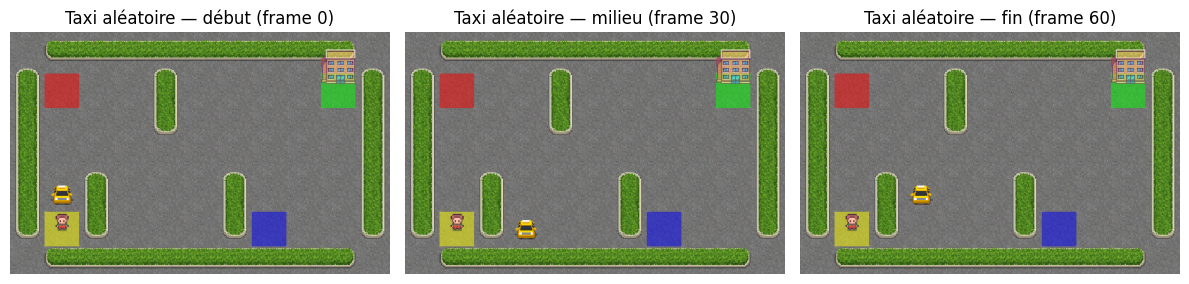

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5728:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2722:(snd_pcm_open_noupdate) Unknown PCM default


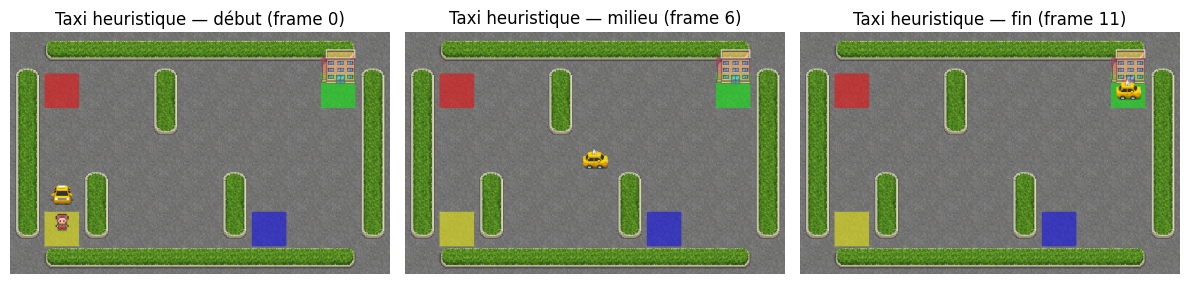

In [21]:
# Capture d'images — Taxi aléatoire et heuristique
frames_taxi_rand = capture_episode_frames("Taxi-v3", policy_taxi_random, seed=7, max_steps=60)
show_selected_frames(frames_taxi_rand, title_prefix="Taxi aléatoire")

frames_taxi_heu = capture_episode_frames("Taxi-v3", policy_taxi_heur, seed=7, max_steps=60)
show_selected_frames(frames_taxi_heu, title_prefix="Taxi heuristique")

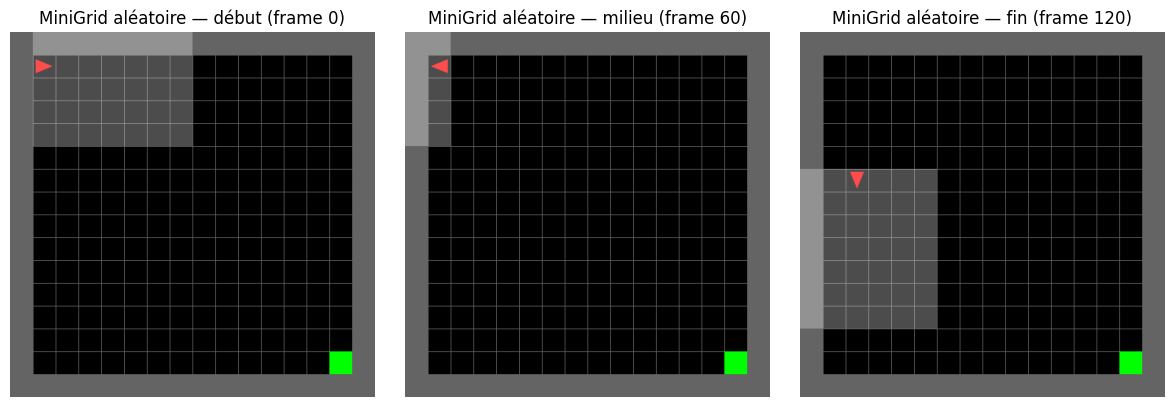

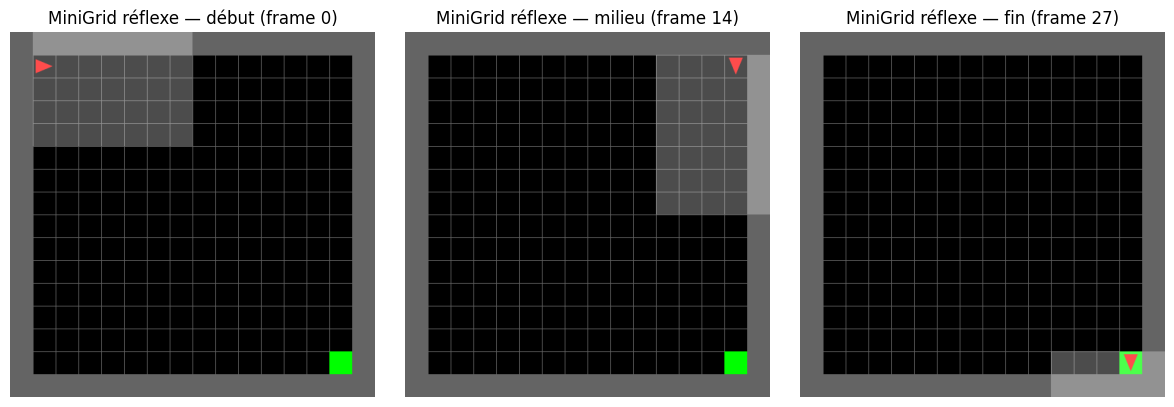

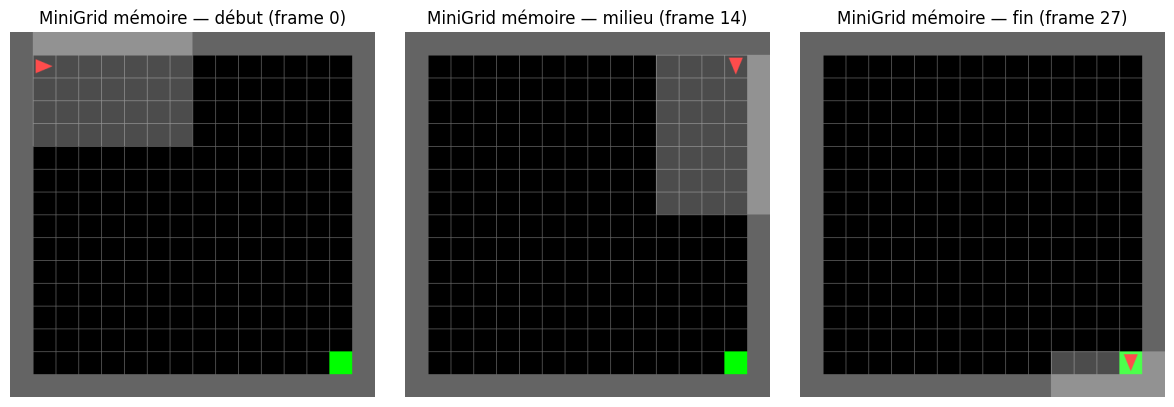

In [22]:
# Capture d'images — MiniGrid aléatoire, réflexe, mémoire
frames_mg_rand = capture_episode_frames(
    "MiniGrid-Empty-16x16-v0", policy_mg_random, seed=0, max_steps=120
)
show_selected_frames(frames_mg_rand, title_prefix="MiniGrid aléatoire")

frames_mg_reflex = capture_episode_frames(
    "MiniGrid-Empty-16x16-v0", policy_mg_reflex, seed=0, max_steps=200
)
show_selected_frames(frames_mg_reflex, title_prefix="MiniGrid réflexe")

# Reset la mémoire interne de la politique à mémoire
_mem_policy_instance["p"] = None
frames_mg_mem = capture_episode_frames(
    "MiniGrid-Empty-16x16-v0", policy_mg_memory, seed=0, max_steps=400
)
show_selected_frames(frames_mg_mem, title_prefix="MiniGrid mémoire")

### Enregistrement vidéo avec `RecordVideo`

In [23]:
from gymnasium.wrappers import RecordVideo

def record_policy_video(env_id, policy_fn, video_folder, seed=0,
                        max_steps=200, episode_name="demo", env_kwargs=None):
    env_kwargs = env_kwargs or {}
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)
    env = gym.make(env_id, render_mode="rgb_array", **env_kwargs)
    env = RecordVideo(
        env, video_folder=str(video_folder),
        name_prefix=episode_name,
        episode_trigger=lambda ep_id: True,
    )
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0
    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1
    env.close()
    return video_folder

In [24]:
# MiniGrid — politique aléatoire et politique à mémoire
out1 = record_policy_video(
    "MiniGrid-Empty-16x16-v0", policy_mg_random,
    video_folder="videos/minigrid_random",
    seed=0, max_steps=150, episode_name="random_policy",
)
print("Vidéo 1 ->", out1)

_mem_policy_instance["p"] = None
out2 = record_policy_video(
    "MiniGrid-Empty-16x16-v0", policy_mg_memory,
    video_folder="videos/minigrid_memory",
    seed=0, max_steps=400, episode_name="memory_policy",
)
print("Vidéo 2 ->", out2)

# Bonus Taxi : politique heuristique
out3 = record_policy_video(
    "Taxi-v3", policy_taxi_heur,
    video_folder="videos/taxi_heuristic",
    seed=7, max_steps=60, episode_name="heuristic_policy",
)
print("Vidéo 3 ->", out3)

# Liste des fichiers générés
for folder in ["videos/minigrid_random", "videos/minigrid_memory", "videos/taxi_heuristic"]:
    p = Path(folder)
    if p.exists():
        print(folder, "->", sorted([f.name for f in p.iterdir()]))

/usr/local/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/user/workspace/videos/minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Vidéo 1 -> videos/minigrid_random


/usr/local/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/user/workspace/videos/minigrid_memory folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Vidéo 2 -> videos/minigrid_memory


/usr/local/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/user/workspace/videos/taxi_heuristic folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
error: XDG_RUNTIME_DIR is invalid or not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5728:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2722:(snd_pcm_open_noupd

Vidéo 3 -> videos/taxi_heuristic
videos/minigrid_random -> ['random_policy-episode-0.mp4']
videos/minigrid_memory -> ['memory_policy-episode-0.mp4']
videos/taxi_heuristic -> ['heuristic_policy-episode-0.mp4']


### Questions d'analyse visuelle

**1. Comportements répétitifs, hésitations ou blocages ?**  
- Politique aléatoire MiniGrid : oscillations quasi sur place, alternance de rotations et de petits pas qui ne ramènent pas l'agent vers l'objectif.  
- Politique réflexe MiniGrid : l'agent longe les murs et peut « tourner en rond » dans un coin quand il ne voit pas le goal.  
- Politique aléatoire Taxi : beaucoup de pickup/dropoff illégaux et d'allers-retours sans progression.

**2. Quelle politique paraît la plus cohérente à l'observation ?**  
Sur Taxi, la politique **heuristique** est clairement la plus cohérente : on voit le taxi se rendre au passager, faire `pickup`, puis se rendre à la destination et faire `dropoff`.  
Sur MiniGrid, la politique **avec mémoire** est plus fluide que la politique réflexe car elle évite les oscillations et attaque l'objectif dès qu'elle le voit.

**3. Le rendu visuel confirme-t-il les indicateurs quantitatifs ?**  
Oui : les politiques qui obtiennent un meilleur taux de succès et moins d'étapes produisent aussi une trajectoire beaucoup plus directe à l'œil. Cela illustre que les métriques agrégées (récompense, longueur, succès) sont bien corrélées à la qualité visuelle du comportement observé.

### Tableau comparatif final (quantitatif + visuel)

| Environnement | Politique | Récompense moy. | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | très négative (~−200 à −800) | très faible | beaucoup de pickup/dropoff illégaux, aucune direction claire |
| Taxi-v3 | Aléatoire contrainte | moins négative | faible à moyen | plus de mouvements valides mais trajet erratique |
| Taxi-v3 | Heuristique | positive (~+7/+8) | ≈ 100 % | trajectoire directe : passager → destination |
| MiniGrid | Aléatoire | ≈ 0 | ≈ 0 % | agent qui tourne sur place, n'atteint jamais le goal |
| MiniGrid | Réflexe | ≈ 0 | faible | longe les murs, se bloque dans les coins |
| MiniGrid | Mémoire minimale | > 0 sur certains épisodes | modeste mais non nul | explore davantage et fonce vers le goal dès qu'il le voit |
